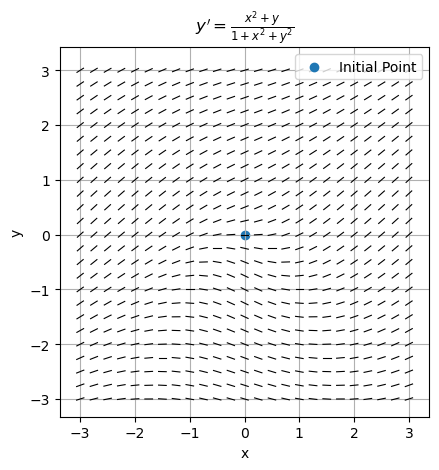

In [1]:
import numpy as np  # operasi numerik
import matplotlib.pyplot as plt  # plotting

# Direction Field (versi dimodifikasi)
def direction_field(x_min, x_max, y_min, y_max, n_step, length, fun, ax):
    
    np.seterr(divide='ignore', invalid='ignore')  # abaikan error pembagian nol
    
    x = np.linspace(x_min, x_max, n_step)  # grid x
    y = np.linspace(y_min, y_max, n_step)  # grid y
    X, Y = np.meshgrid(x, y)  # grid 2D
    
    slope = fun(X, Y)  # hitung kemiringan dy/dx
    
    slope = np.clip(slope, -100, 100)  
    # membatasi nilai ekstrem (lebih rapi dari inf handling manual)

    delta = length * np.cos(np.arctan(slope))  # komponen horizontal
    X1 = X - delta  # titik awal
    X2 = X + delta  # titik akhir
    Y1 = slope * (X1 - X) + Y  # koordinat Y awal
    Y2 = slope * (X2 - X) + Y  # koordinat Y akhir
    
    ax.plot([X1.ravel(), X2.ravel()], [Y1.ravel(), Y2.ravel()], 
            color='black', linewidth=0.8)  # plot garis kecil


# Differential equation (diubah sedikit)
def my_ode(x, y):
    return (x**2 + y) / (1 + x**2 + y**2)  
    # bentuk baru (lebih stabil, tidak banyak singularitas)


# Plot
fig, ax1 = plt.subplots()

direction_field(
    x_min=-3, x_max=3,   # diperluas
    y_min=-3, y_max=3,
    n_step=25,           # jumlah grid diubah
    length=0.07,         # panjang garis diubah
    fun=my_ode,
    ax=ax1
)

# Tambahkan titik awal contoh solusi (nilai plus)
ax1.scatter(0, 0, label="Initial Point")

ax1.set_xlabel('x')  # label sumbu x
ax1.set_ylabel('y')  # label sumbu y
ax1.set_title(r"$y' = \frac{x^2 + y}{1 + x^2 + y^2}$")  # judul baru
ax1.axis('square')  # skala sama
ax1.grid()  # grid
ax1.legend()  # legenda

plt.show()

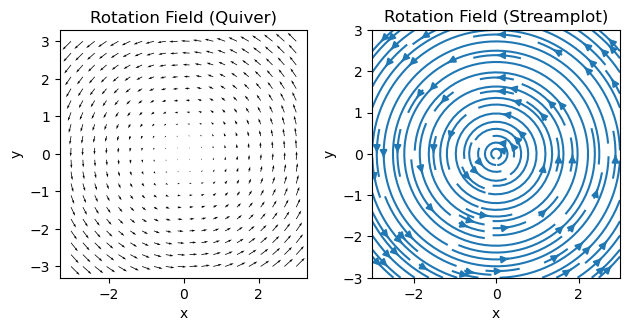

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 20)  # grid lebih rapat biar halus
y = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x, y)

# sistem rotasi sederhana (lingkaran)
dx_dt = -Y
dy_dt = X

fig = plt.figure()

ax1 = fig.add_subplot(1, 2, 1)
ax1.quiver(X, Y, dx_dt, dy_dt)
ax1.set_title('Rotation Field (Quiver)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.axis('square')

ax2 = fig.add_subplot(1, 2, 2)
ax2.streamplot(X, Y, dx_dt, dy_dt, density=1.2)
ax2.set_title('Rotation Field (Streamplot)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.axis('square')

fig.tight_layout()
plt.show()

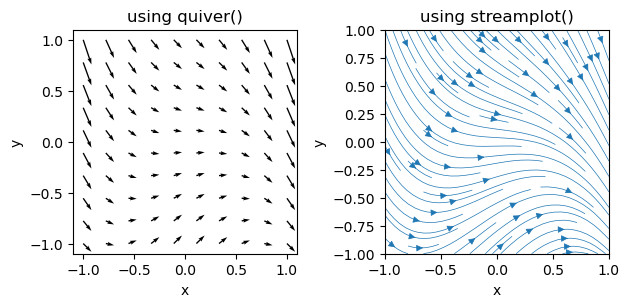

In [3]:
import numpy as np  # import numpy untuk operasi array
import matplotlib.pyplot as plt  # import matplotlib untuk plotting

x = np.linspace(-1, 1, 10)  # titik grid sumbu x
y = x  # titik grid sumbu y
X, Y = np.meshgrid(x, y)  # membuat grid 2D

dx_dt = np.ones_like(X)  # komponen arah x (konstan)
dy_dt = - Y - 2 * X**2  # komponen arah y

# Making plot 
fig = plt.figure()  
ax1 = fig.add_subplot(1, 2, 1)  # subplot quiver
ax1.quiver(X, Y, dx_dt, dy_dt)  # plot medan vektor (panah)
ax1.set_title('using quiver()')  # judul plot
ax1.set_xlabel('x')  # label sumbu x
ax1.set_ylabel('y')  # label sumbu y
ax1.axis('square')  # skala sama

ax2 = fig.add_subplot(1, 2, 2)  # subplot streamplot
ax2.streamplot(X, Y, dx_dt, dy_dt, linewidth=0.5)  # garis aliran vektor
ax2.set_title('using streamplot()')  # judul plot
ax2.set_xlabel('x')  # label sumbu x
ax2.set_ylabel('y')  # label sumbu y
ax2.axis('square')  # skala sama

fig.tight_layout()  # rapikan layout

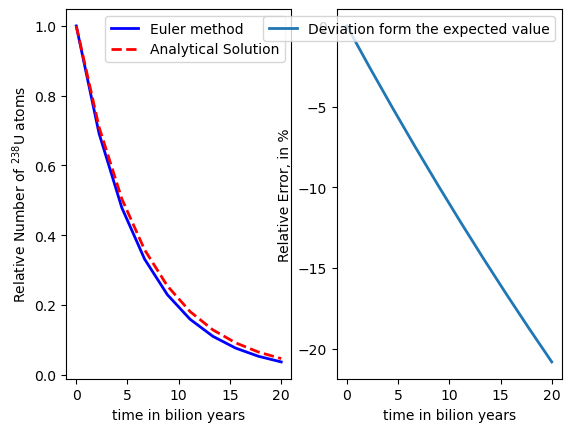

In [3]:
import matplotlib.pyplot as plt  # import matplotlib untuk plotting
import numpy as np  # import numpy untuk perhitungan numerik

# Euler Method
def euler_method(n0, decay_const, t_final, n_t_steps):  # fungsi metode Euler
    iterations = n_t_steps  # jumlah iterasi
    delta_t = t_final/n_t_steps  # langkah waktu
    t1 = np.linspace(0, iterations*delta_t, iterations)  # array waktu
    n1 = np.zeros(t1.shape, float)  # array hasil numerik
    n1[0]=n0  # kondisi awal
    
    for i in range(0,len(t1)-1):  # iterasi Euler
        n1[i+1] = n1[i] * (1 - decay_const * delta_t )  # update nilai
    
    n1r = n1/n0  # normalisasi hasil
    return n1, n1r, t1  # kembalikan hasil

ne, ner, te = euler_method(n0=10000, decay_const=1.54e-1, t_final=20, n_t_steps=10)  # solusi Euler

# Analytical solution
def analytical_solution(n0, decay_const, t_final, n_t_steps):  # solusi eksak
    intermediate_points = n_t_steps  # jumlah titik
    delta_t = t_final/n_t_steps  # langkah waktu
    t2 = np.linspace(0, intermediate_points*delta_t, intermediate_points)  # waktu
    n2 = n0 * np.exp(-decay_const * t2 )  # solusi eksponensial
    n2r = n2/n0  # normalisasi
    return n2, n2r, t2  # kembalikan hasil

na, nar, ta = analytical_solution(n0=10000, decay_const=1.54e-1, t_final=20, n_t_steps=10)  # solusi analitik

euler_rel_error = 100*(ne-na)/na  # error relatif Euler terhadap analitik

fig = plt.figure()  
ax1 = fig.add_subplot(1, 2, 1)  # subplot 1
ax1.plot(te, ner, linestyle="-", linewidth=2, color='blue', label='Euler method') #hasil Euler
ax1.plot(ta, nar, linestyle="--", linewidth=2, color='red', label='Analytical Solution') #hasil analitik
ax1.set_ylabel('Relative Number of $^{238}$U atoms')  # label y
ax1.set_xlabel('time in bilion years')  # label x
ax1.legend()  # legenda

ax2 = fig.add_subplot(1, 2, 2)  # subplot 2
ax2.plot(te, euler_rel_error, linestyle="-", linewidth=2, label='Deviation form the expected value')  # error
ax2.set_ylabel('Relative Error, in %')  # label y
ax2.set_xlabel('time in bilion years')  # label x
ax2.legend()  # legenda

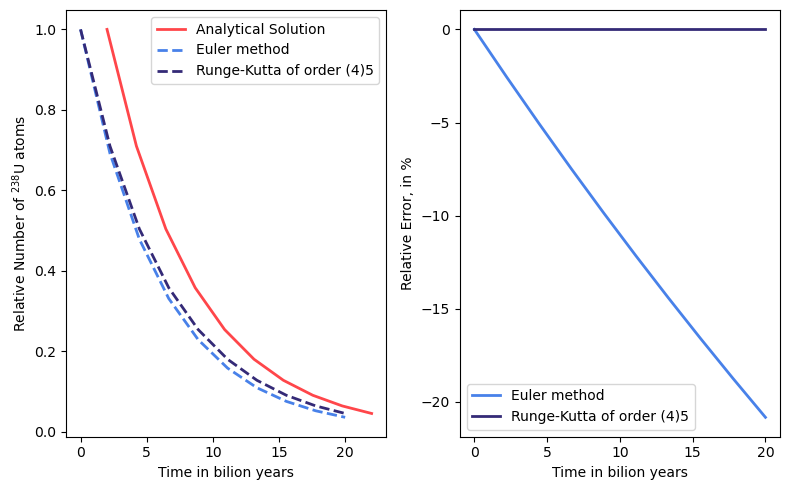

In [5]:
import matplotlib.pyplot as plt  # import matplotlib untuk plotting
import numpy as np  # import numpy untuk perhitungan numerik
from scipy.integrate import ode  # import solver ODE dari scipy

# using scipy.integrate.ode
def ode_sol(n0, decay_const, t_final, n_t_steps):  # fungsi solusi ODE dengan Runge-Kutta
    intermediate_points = n_t_steps  # jumlah titik waktu
    t3 = np.linspace(0,t_final, intermediate_points)  # array waktu
    n3 = np.zeros(t3.shape, float)  # array hasil
    
    def f(t, y, decay_const):  # fungsi diferensial
        return  - decay_const * y  # persamaan peluruhan
    
    solver = ode(f).set_integrator('dopri5')  # metode Runge-Kutta (4/5)
    y0 = n0  # kondisi awal
    t0 = 0  # waktu awal
    solver.set_initial_value(y0, t0)  # set kondisi awal
    solver.set_f_params(decay_const)  # parameter konstanta peluruhan
    
    k=1  # indeks waktu
    n3[0] = n0  # nilai awal
    
    while solver.successful() and solver.t < t_final:  # iterasi solver
        n3[k] = solver.integrate(t3[k])[0]  # solusi numerik
        k += 1  # naik indeks
    
    n3r = n3 / n0  # normalisasi hasil
    return n3, n3r, t3  # kembalikan hasil


# Analytical solution
na, nar, ta = analytical_solution(n0=10000, decay_const=1.54e-1, t_final=20, n_t_steps=10)  # solusi analitik

# Euler method
ne, ner, te = euler_method(n0=10000, decay_const=1.54e-1, t_final=20, n_t_steps=10)  # solusi Euler

nuler_rel_error = 100*(ne-na)/na  # error Euler

# Runge-Kutta (ODE solver)
n_ode, n_oder, tode = ode_sol(n0=10000, decay_const=1.54e-1, t_final=20, n_t_steps=10)  # solusi ODE
ode_rel_error = 100*(n_ode - na) / na  # error Runge-Kutta

# Make the plot
fig = plt.figure(figsize=(8,5))  
ax1 = fig.add_subplot(1, 2, 1)  # subplot 1
ax1.plot(ta + 2, nar, linestyle="-", linewidth=2, label='Analytical Solution', c='#ff464a')  # solusi analitik
ax1.plot(te, ner, linestyle="--", linewidth=2, label='Euler method', c='#4881e9')  # Euler
ax1.plot(tode, n_oder, linestyle="--", linewidth=2, label='Runge-Kutta of order (4)5', c='#342a77')  # RK45
ax1.set_ylabel('Relative Number of $^{238}$U atoms')  # label y
ax1.set_xlabel('Time in bilion years')  # label x
ax1.legend()  # legenda

ax2 = fig.add_subplot(1, 2, 2)  # subplot 2
ax2.plot(te, euler_rel_error, linestyle="-", linewidth=2, c='#4881e9', label='Euler method')  # error Euler
ax2.plot(tode, ode_rel_error, linestyle="-", linewidth=2, c='#342a77', label='Runge-Kutta of order (4)5')  # error RK
ax2.set_ylabel('Relative Error, in %')  # label y
ax2.set_xlabel('Time in bilion years')  # label x
ax2.legend()  # legenda

fig.tight_layout()  # rapikan layout

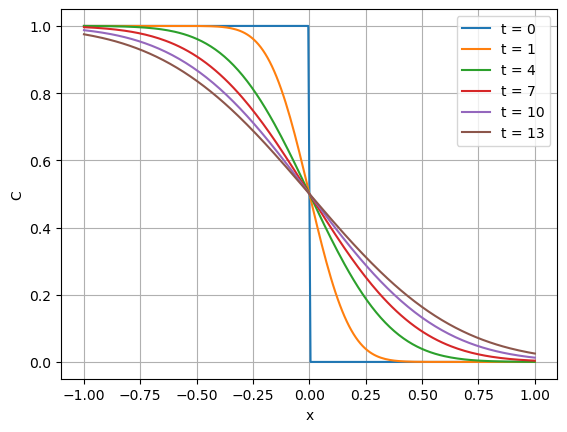

In [6]:
import numpy as np  # import numpy untuk perhitungan numerik
from scipy import special  # import fungsi khusus (erfc)
import matplotlib.pyplot as plt  # import matplotlib untuk plotting

def plane_diff_1d(t, D, x0=0, xmin=-1, xmax=1, c_left=1, c_right=0, num_points=200):  # fungsi difusi 1D
     n = num_points  # jumlah titik grid
     x = np.linspace(xmin, xmax, n)  # domain x
     delta_c = c_left - c_right  # selisih konsentrasi awal
     
     c0 = np.piecewise(x, [x < x0, x >= x0], [c_left, c_right])  # kondisi awal konsentrasi
     c = 0.5 * delta_c * (special.erfc((x - x0)/(2 * np.sqrt(D * t))))  # solusi difusi analitik
  
     return x, c, c0  # kembalikan posisi dan konsentrasi

D = 0.01  # koefisien difusi

fig, ax = plt.subplots()  

for t in range(1, 14, 3):  # variasi waktu
    x, c, c0 = plane_diff_1d(t=t, D=D)  # hitung solusi difusi
    
    if t==1:  # hanya sekali untuk kondisi awal
        plt.plot(x, c0, label="t = 0")  # plot kondisi awal
    
    leg = "t = " + str(t)  # label waktu
    ax.plot(x, c, label=leg)  # plot solusi difusi

ax.grid()
ax.set_xlabel('x')  # label sumbu x
ax.set_ylabel('C')  # label sumbu konsentrasi
ax.legend()  # legenda

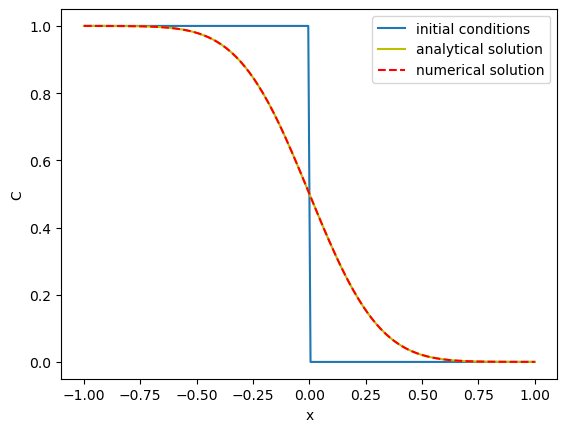

In [7]:
def ftcs(u, D, h, dt):  # skema FTCS untuk persamaan difusi
    
    d2u_dx2 = np.zeros(u.shape, float)  # array turunan kedua ruang
    
    for i in range(1,len(u)-1):  # titik interior
        # Central difference scheme in space
        d2u_dx2[i] = (u[i+1] - 2*u[i] + u[i-1]) / h**2  # turunan kedua numerik
        
    # Neumann boundary conditions at i=0 and i=len(u)-1
    i=0
    d2u_dx2[i] = (u[i+1] - 2 * u[i] + u[i]) / h**2  # batas kiri
    i=len(u)-1
    d2u_dx2[i] = (u[i] - 2 * u[i] + u[i-1]) / h**2  # batas kanan
    
    # Euler method for the time domain
    u1 = u + dt * D * d2u_dx2  # update waktu (skema eksplisit)
    return u1  # hasil iterasi waktu
    
dt = 0.001  # langkah waktu
tf = 3  # waktu akhir

def compute_d_const(u, d, h, dt, tf):  # simulasi sampai waktu tf
    
    nsteps = tf/dt  # jumlah iterasi waktu
    u1 = u  # kondisi awal
    
    for i in range(int(nsteps)):  # iterasi waktu
        u1 =  ftcs(u1, D, h, dt)  # update solusi
    
    return u1  # hasil akhir

x, c, c0 = plane_diff_1d(t=tf, D=D)  # solusi analitik untuk pembanding

h = x[1] - x[0]  # ukuran grid ruang
u = c0  # kondisi awal
c1 = compute_d_const(u, D, h, dt, tf)  # solusi numerik FTCS

fig, ax = plt.subplots()  
ax.plot(x,c0, label='initial conditions')  # kondisi awal
ax.plot(x,c,'y', label='analytical solution')  # solusi analitik
ax.plot(x,c1,'r--', label='numerical solution')  # solusi numerik
ax.set_xlabel('x')  # label sumbu x
ax.set_ylabel('C')  # label konsentrasi
ax.legend()  # legenda

In [8]:
def numpy_ftcs(u, D, h, dt):  # FTCS versi vectorized (NumPy)

    d2u_dx2 = np.zeros(u.shape, float)  # array turunan kedua
    
    d2u_dx2[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / h**2  # central difference (vectorized)

    # Neumann boundary conditions at i=0 and i=len(u)-1
    i = 0
    d2u_dx2[i] = (u[i+1] - 2 * u[i] + u[i]) / h**2  # batas kiri
    
    i = len(u)-1
    d2u_dx2[i] = (u[i] - 2 * u[i] + u[i-1]) / h**2  # batas kanan

    # Euler method for time stepping
    u1 = u + dt * D * d2u_dx2  # update solusi
    return u1  # hasil langkah waktu

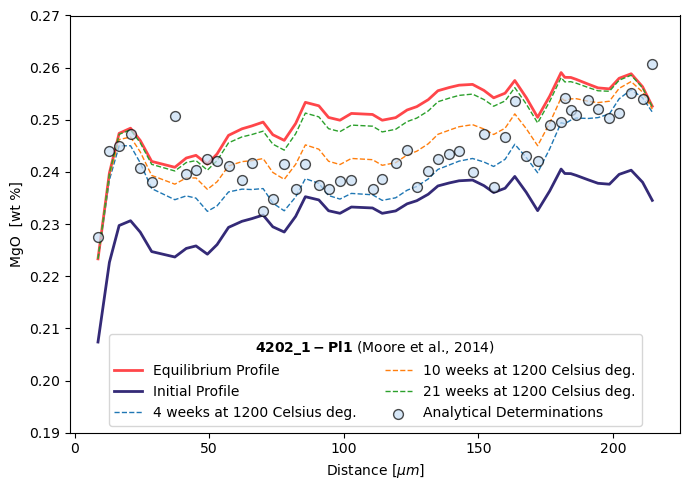

In [5]:
import numpy as np  # import numpy untuk operasi numerik
import matplotlib.pyplot as plt  # import matplotlib untuk plotting
import pandas as pd  # import pandas untuk membaca data Excel

# Model parameters
T = 1200.0  # suhu (°C)
dx = 4.12  # jarak rata-rata antar titik (mikron)
dt = 0.9 * 1e4  # langkah waktu
RT = 8.3144 * (T + 273.15)  # konstanta gas * suhu absolut
R = dt / dx ** 2  # parameter skala difusi numerik

# Initial Conditions
my_dataset = pd.read_excel(r'C:\Users\ThinkPad X13 Yoga\Documents\CODING\python_earth_science_book-main\python_earth_science_book-main\code\chapter_08\Moore_Phd.xlsx', sheet_name='Sheet1')  # membaca data Excel
my_distance = my_dataset.Distance.values  # jarak analisis
Mg_C = my_dataset.MgO.values  # data MgO
An = my_dataset.An_mol_percent.values  # data An
An = An / 100  # konversi persen ke fraksi
An_unsmoothed = An  # data awal An
An_smoothed = np.full(len(An),0.)  # array untuk An yang sudah dihaluskan

# Smoothing the An profile to avoid numerical artifacts
D_smoot = np.full(len(An),0.0005)  # koefisien smoothing
for i in range(2):  # iterasi smoothing
    An_smoothed[1:-1] =  An_unsmoothed[1:-1] + R * D_smoot[1:-1] * (An_unsmoothed[2:] - 2 * An_unsmoothed[1:-1] + An_unsmoothed[:-2])  # smoothing numerik
    An_smoothed[0] = An[0]  # batas kiri
    An_smoothed[len(An)-1] = An[len(An)-1]  # batas kanan
    an_unsmoothed = An_smoothed  # update data (catatan: overwrite variabel)

# difusi Mg tergantung komposisi An dan suhu
D_Mg = 2.92 * 10**(-4.1 * An_smoothed - 3.1)*np.exp(-266 * 1e3/RT)*1e12  # koefisien difusi Mg

fig, ax = plt.subplots(figsize=(7,5))  # membuat figure

# Initial and Equilibrium Profiles
A = - 21882  # konstanta model
B = - 26352  # konstanta model
K = np.exp((A*An_smoothed+B)/RT)  # faktor kesetimbangan
c_eq = 8.4 * K  # konsentrasi kesetimbangan
c_init = 7.8 * K  # kondisi awal
ax.plot(my_distance, c_eq, linewidth=2, color='#ff464a', label ='Equilibrium Profile')  # plot equilibrium
ax.plot(my_distance, c_init,linewidth=2,  color='#342a77', label='Initial Profile')  # plot initial

# Numerical solution
colors = ['#4881e9','#e99648','#e9486e']  # warna plot
t_final_weeks = np.array([4,10,21])  # waktu simulasi (minggu)

for t_w, color in zip(t_final_weeks,colors):  # loop tiap waktu

    C_Mg_new = np.full(len(c_eq),0.)  # array hasil baru
    d2An = np.full(len(c_eq),0.)  # turunan kedua An
    d2C_Mg = np.full(len(c_eq),0.)  # turunan kedua Mg
    dD_Mg = np.full(len(c_eq),0.)  # turunan difusi Mg
    dC_Mg = np.full(len(c_eq),0.)  # turunan pertama Mg
    dAn = np.full(len(c_eq),0.)  # turunan pertama An
    
    C_Mg = c_init  # kondisi awal Mg
    t_final = int(604800 * t_w/dt)  # konversi minggu ke langkah waktu
    
    for i in range(t_final):  # iterasi waktu
        
        # boundary conditions: rim set ke kesetimbangan
        C_Mg_new[0] = c_eq[0]
        C_Mg_new[len(c_eq)-1] = c_eq[len(c_eq)-1]
        
        # finite difference (turunan ruang)
        d2An[1:-1] = (An_smoothed[2:] - 2 * An_smoothed[1:-1] + An_smoothed[:-2])
        d2C_Mg[1:-1] = C_Mg[2:] - 2 * C_Mg[1:-1] + C_Mg[:-2]
        dD_Mg[1:-1] =  (D_Mg[2:]-D_Mg[:-2])/2
        dC_Mg[1:-1] = (C_Mg[2:]-C_Mg[:-2])/2
        dAn[1:-1] =  (An_smoothed[2:]-An_smoothed[:-2])/2
        
        # update persamaan difusi Mg dengan coupling komposisi
        C_Mg_new[1:-1] = C_Mg[1:-1] + R * (
            (D_Mg[1:-1] * d2C_Mg[1:-1] + dD_Mg[1:-1] * dC_Mg[1:-1]) 
            - (A/RT) * (
                D_Mg[1:-1] * dC_Mg[1:-1] * dAn[1:-1]  
                + C_Mg[1:-1] * dD_Mg[1:-1] * dAn[1:-1] 
                + D_Mg[1:-1] * C_Mg[1:-1] * d2An[1:-1]
            )
        )
        C_Mg = C_Mg_new  # update solusi
    
    ax.plot(my_distance, C_Mg_new, linestyle='--', linewidth=1,
            label= str(t_w) + ' weeks at 1200 Celsius deg.')  # plot hasil simulasi
    
ax.scatter(my_distance, Mg_C, marker='o', c='#c7ddf4',
           edgecolors= 'k', s=50, label='Analytical Determinations',
           zorder=100, alpha=0.7)  # data eksperimen

ax.set_ylim(0.19,0.27)  # batas sumbu y
 
time_sec = t_final * dt  # waktu akhir (detik)
time_weeks = time_sec / 604800  # konversi ke minggu

ax.legend(title=r'$\bf{4202\_1-Pl1}$ (Moore et al., 2014)',
          ncol=2, loc='lower center')  # legenda
ax.set_xlabel(r'Distance [$\mu m$]')  # label x
ax.set_ylabel('MgO  [wt %]')  # label y

fig.tight_layout()  # rapikan layout